## MACHINE LEARNING 


MODULE 8 | LESSON 2


---

# **Linear Models in TensorFlow: Timing Factors and Smart-Beta Strategies** 

|  |  |
|:---|:---|
|**Reading Time** |  90 minutes |
|**Prior Knowledge** | Linear Algebra, Python  |
|**Keywords** | Linear Regression, Classification, Machine learning |


---

*In this lesson, we will take our first look at a neural network (NN) algorithm in the simple framework of linear regression. As you will see, there are lots of different applications of NNs. We are going to tackle a finance one. More specifically, we will try to use this deep learning (not so deep, yet) tool to predict the performance of smart-beta strategies. In this lesson, we will tackle this problem using linear regression (a single-layer, fully-connected NN). In lesson 3 of this module, we will repeat this same exercise using multilayer perceptrons (MLP), a real (but simple) deep network. Then, we will evaluate the benefits of more complex networks with several hidden layers.*

*But before going there, what are smart-beta strategies?*

## **1. Smart-Beta Strategies (Factor Investing)**


*Smart-beta* strategies are basically those based on the different market anomalies known as **risk factors**. Hence, sometimes, you will see these also referred to as **factor investing**.

- **What is a *factor*?**

A factor is simply a characteristic (e.g., macroeconomic, style, etc.) that explains the cross-section of stock returns. The academic literature has, for a long time now, investigated the characteristics that defy the market efficient view. In the process, researchers have come up with a good number of factors (or market anomalies) that help explain the cross-section of stock returns in addition to the exposure to market return (CAPM $\beta$).

*(If you are not familiar with the CAPM model, you can check a very intuitive (and old) article on HBR here: https://hbr.org/1982/01/does-the-capital-asset-pricing-model-work )*

So these factors help explain the cross-section of stock returns, but how exactly? Let's illustrate this with the example of the **value** factor, one that you all have probably heard of at some point. 

Value is tightly linked to a firms' **book-to-market (B/M)** ratio, which is simply the market price of a stock over its book value. This acts as a direct indicator of the relative prospects of the firm. In probably one of the most famous finance papers of all time, Fama and French determined that firms with a lower B/M tend to be strong performers (on average), while firms with a high B/M are usually weak. Importantly, this out- and under- performance is not explained by other known characteristics such as exposure to market risk or firm size. 

*Here, you can have a look at some early papers by Fama and French on the subject.*

- Fama, Eugene F., and Kenneth R. French. "The Cross-Section of Expected Stock Returns." *The Journal of Finance*, vol. 47, no. 2, 1992, pp. 427-465, https://www.jstor.org/stable/2329112.

- Fama, Eugene F., and Kenneth R. French. "Common Risk Factors in the Returns on Stocks and Bonds." *Journal of Financial Economics*, vol. 33, no. 1, 1993, pp. 3-56, (https://doi.org/10.1016/0304-405X(93)90023-5)

So, the bottom line is that according to these studies, we should be able to make money, on average, by simply going long on a portfolio of firms with very low B/M and/or going short on a portfolio of firms with high B/M. The question now is why?

There are various explanations for this phenomenon. Probably the most accepted one, and the one defended by Fama and French in all their subsequent papers, is that B/M proxies for a **common risk factor** in the cross-section of stock returns. That is, the kind of strategy we described yields a profit because it also implies assuming more risk. For example, since high market prices relative to book values (that is, low B/M) are probably driven by better future prospects of the firm, there is an underlying risk of realization of these prospects. 

Hence, B/M constitutes a factor that helps explain the cross-section of stock returns, but also a characteristic that would aid in selecting our investments. We could then construct a **B/M factor (or value factor)** that goes long in a portfolio of the 10\% of firms with the lowest B/M, and short-sells a portfolio of the 10\% of firms with the highest B/M. Such a portfolio would earn a **factor premium**. Since there are quite a few factors identified by the academic literature (some more widely accepted as such than others), there are a bunch of different characteristics that we can use for our investments.

(*Here, you can find a recent paper by Harvey et al. (2016) exploring the "zoo" of new factors found in the academic literature. For some of them, the evidence supporting their condition of "common risk factor" is only weak, but some are unambiguously classified as such:*  https://academic.oup.com/rfs/article/29/1/5/1843824?login=false )


- **Factor Investing**

The kind of investment strategy that relies on these factors is usually referred to as ***factor investing*** or ***smart beta*** strategies. Indeed, the last few years have witnessed a wild explosion in the use of these strategies. Since the trading decision (e.g., buy low B/M firms, short-sell high B/M firms) of these strategies is very systematic and has a clear rule, many important investment managers like Vanguard or BlackRock have specifically designed products using these notions. Most often, these investment managers create products like ETFs (exchange-traded funds) that track one (or several) of these factors. But it is not only widely known passive investors such as Vanguard or BlackRock that rely on factor investing as a product to market to clients. Prominent players do also undertake this systematic approach for their own gain, such as  AQR, a hedge fund. Next, you can see each of these players' views on factor investing:

- [Vanguard's factor-based strategies](https://advisors.vanguard.com/investments/approach/factor-based-strategies#overview)

- [BlackRock's factor-based investing](https://www.blackrock.com/uk/professionals/solutions/factor-based-investing)

- [AQR's views on factor investing](https://www.aqr.com/Learning-Center/Systematic-Equities/Systematic-Equities-A-Closer-Look)

- [Fidelity's overview of factor investing](https://www.fidelity.com/bin-public/060_www_fidelity_com/documents/fidelity/fidelity-overview-of-factor-investing.pdf)


- **Momentum Factor**

In this notebook, we are going to focus on one of the most profitable and persistent factors over time: **momentum**. Individual stocks' momentum is, in its simplest form, a concept similar to *inertia*. It refers to the documented fact that stocks that perform the best (worst) over a three- to 12-month period tend to continue to perform well (poorly) over the subsequent three to 12 months:

- *Here, you have the first paper that formally documented the returns to a momentum strategy by Jegadeesh and Titman*: https://www.jstor.org/stable/2328882

Momentum is one of the most widely used factor strategies, as it is easy to implement, requires a lower amount of input data, and offers great returns over time. In the following paper, Asness et al. document a prevalence of value and momentum factors in many asset classes:

- Asness, Clifford S., et al. "Value and Momentum Everywhere." *The Journal of Finance*, vol. 68, no. 3, 2013, pp. 929-985, https://onlinelibrary.wiley.com/doi/abs/10.1111/jofi.12021?casa_token=vxQDrj_UikoAAAAA:hXo8tu-G8xQb6CxRiS1C2hk8zLyYM6rlYrl3E8DqUnTY2TG1m_F2me8XUChr9S88W-csmUczqZQ44E8. 


- **Factor Timing**

At this point, we know that investing in these so-called factors seems a reliable source of returns in the long run. But, of course, the performance of these different factors is not always the same across time. Some factors perform better than others under certain circumstances and vice versa. What will be more interesting to us is being able to perform some **factor timing**. That is, similar to market timing, we can go long in the factor when we predict that a specific characteristic is going to do especially well and go short on it when we predict it is going to do badly. 

Despite this effective strategy, unfortunately, factor timing is not so easy to do in practice. Being able to time the factor would mean that past returns of the factor serve well in explaining the future performance of the factor. The prediction of past factor returns is actually a very challenging task. Put it in Cliff Asness's (Founder & Managing Principal at AQR) words: ***"Factor timing is likely even harder than market timing***."

There are, still, some papers in the academic literature that tackle the question of factor timing, specially for momentum, with mixed results. This is actually dense literature, but we offer you some examples of papers exploring this avenue:

- Daniel, Kent, and Tobias J. Moskowitz. "Momentum Crashes." *Journal of Financial Economics*, vol. 122, no. 2, 2016, pp. 221-247, https://www.sciencedirect.com/science/article/pii/S0304405X16301490.

- Ehsani, Sina, and Juhani T. Linnainmaa. "Factor Momentum and the Momentum Factor." *The Journal of Finance*, vol. 77, no. 3, 2022, pp. 1877-1919, https://onlinelibrary.wiley.com/doi/full/10.1111/jofi.13131?casa_token=oWY7-8sCYqkAAAAA%3A-HrzsyemLuXf0lQyYMT9vxFNyNQugJsMfaY39EAeTCjClDlAPHdU_fqS4z2-LpVrUO7li2wQmIphYXA.

- Moskowitz, Tobias J., et al. "Time Series Momentum." *Journal of Financial Economics*, vol. 104, no. 2, 2012, pp. 228-250, https://www.sciencedirect.com/science/article/pii/S0304405X11002613.

- Huang, Dashan, et al. "Time Series Momentum: Is It There?" *Journal of Financial Economics*, vol. 135, no. 3, 2020, pp. 774-794, https://core.ac.uk/download/pdf/287750773.pdf.

- **What are we going to do in this notebook then?**

In this notebook, we will build a neural network, under a linear model, that aims to predict the future returns of the momentum factor. If we are successful in our endeavor, this could grant us with a very valuable investment strategy to allocate our money!


As you can probably guess at this point, a linear model is not going to offer a decent prediction of future momentum returns. However, this is as good excuse as any to learn how to build a simple deep learning model. In fact, in the last lesson of the module we will revisit this problem under a more complex (although still not too complex) neural network. This way, we will be able to observe the power of deep learning in these kinds of finance prediction problems.

## **2. Data Sources**

First and foremost, in order to build a deep learning model, we need data. In this case, we are going to take as inputs the returns from a momentum factor. Using these inputs, we will then aim to predict next period momentum factor returns using as inputs past returns. If we succeed, this means there is a way to time the momentum factor so that a strategy that goes long or short in the factor when the prediction indicates so should yield a better return than a simple buy-and-hold strategy. First, we will use deep learning to build our prediction model, then we will see if the resulting strategy does outperform.

- **Which input data and where do we obtain it?**

As mentioned before, the data for evaluating the timing of the momentum factor is actually somewhat easy to obtain because it only requires past returns of the momentum factor. 

Remember that constructing a momentum factor implies going long on a portfolio of top recent winners (say, the top 10% of firms that did best in the recent past) and short on a portfolio of top recent losers (say, the top 10% that did worst in the recent past). There are many ways (i.e., time-horizons) to construct the momentum factor portfolio returns. Here, we will stick to the classic definition and compute the momentum factor using the returns from the prior (-2, -12) months. That is, if we were to invest in the momentum factor portfolio today at time $t$, we will take the returns of our universe of firms from $t-12$ months to $t-2$ months. The top 10% of firms that did best in that period will be our recent winners and, thus, we will be going long on them. Conversely, the 10% of firms with the poorest returns in the period will be our recent losers and we will be going short on those stocks. The return of the momentum factor tomorrow will be the return of such a portfolio from $t$ to $t+1$ day. 

While constructing such data is a somewhat easy task, it will get easier for us. Here, we will rely on Prof. Ken French's data library, which contains freely available data on a lot of different portfolios sorted by characteristics (e.g., factors). This is a vast and handy database to have in mind whenever you are undertaking these kind of tasks:

- Prof. Ken French's Data Library: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

Now, interestingly for us, one of the pieces of data in Prof. French's library is the daily return of the momentum portfolio ($t-2$, $t-12$), together with the returns of the 10 portfolios resulting from sorting stocks into deciles according to their past performance. More specifically, this will be the data we will be using:

- Daily returns of 10 Portfolios Formed Daily on Momentum: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_10_port_form_pr_12_2_daily.html

So, now that we know where to find the data for our deep learning model, let's begin building it!


## **3. Timing Momentum with (Linear Regression) Neural Networks**

Let's start by visualizing the type of regression problem that we are going to encounter here: linear regression. This is the type of model that we will face:

$$
\begin{equation*}
 y = Xw + b
\end{equation*}
$$

\
Now, we need to make a few decisions in order to move forward. We will need to decide on the number of inputs and what inputs are we going to consider. Similarly, we need to decide which future return of the momentum factor we are going to try to predict. Before making those decisions, however, it may be informative to look at the actual data:

In [1]:
import numpy as np
import pandas as pd

We will upload the file that contains the daily returns of 10 portfolios sorted on their past (-2, -12) months' returns:

In [2]:
route = "10_Portfolios_Prior_12_2_Daily.csv"

In [3]:
# Read the csv file again with skipped rows
df = pd.read_csv(route, index_col=0)
# Format the date index
df.index = pd.to_datetime(df.index, format="%Y%m%d")
# Build the MOM strategy: Long "Hi PRIOR" and Short "Lo PRIOR"
df["Mom"] = df["Hi PRIOR"] - df["Lo PRIOR"]
df.head()

,Lo PRIOR,PRIOR 2,PRIOR 3,PRIOR 4,PRIOR 5,PRIOR 6,PRIOR 7,PRIOR 8,PRIOR 9,Hi PRIOR,Mom
1926-11-03,-0.12,0.60,-0.09,0.30,-0.51,-0.22,-0.12,0.50,0.13,1.28,1.40
1926-11-04,0.65,1.82,1.34,0.61,1.01,0.64,0.82,0.44,0.48,0.40,-0.25
1926-11-05,-0.84,-0.77,-0.22,-0.15,-0.02,-0.02,-0.07,0.36,0.20,0.08,0.92
1926-11-06,1.03,0.28,0.24,0.40,0.19,0.64,0.10,0.10,0.39,-0.68,-1.71
1926-11-08,-0.06,0.11,1.78,0.28,0.36,0.23,0.30,1.17,0.58,-0.18,-0.12


Now, as you can see, we have daily data on the return of each of these portfolios, courtesy of Prof. French, from November 3, 1926. Also, note that we are constructing the returns of the **momentum factor (portfolio)** simply as the returns from buying the stocks in the top decile ('Hi PRIOR'), and short-selling the stocks in the bottom decile ('Lo PRIOR'). Thus, for, say, November 3, 1926, the return of the **'Mom'** portfolio are: $1.28 -(-0.12) = 1.40\%$

Let's next discuss the different inputs and outputs we are going to consider:

### **3.1 Inputs and Outputs**

Now, at this point in our task, it is clear that our aim is in predicting the future return of the Mom portfolio. It is not ex-ante clear which time-horizon of the Mom portfolio returns we should consider for our predictions. In principle, it does not make too much sense to predict a very short time-span nor a very long one. **For this example, let's try to predict the return of the next 60 days**. This will be our **output** variable. Then, you can play around with the code to check other time-spans.

The case of **inputs** requires more investigation. Once again, it is not ex-ante clear, but there are several papers in the literature that have already done some of the job for us. Specifically, the academic literature (see below) finds that the returns from the past: 10, 25, 60, 120, and 240 days are relevant in assessing future returns of the Momentum factor. 

We thus calculate returns on these different horizons for the Mom portfolio, but also for the 'Hi' and 'Lo' ones, and use all as inputs:

In [4]:
df["Ret"] = df["Mom"]
df["Ret10_MOMi"] = df["Mom"].rolling(10).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret25_MOMi"] = df["Mom"].rolling(25).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret60_MOMi"] = df["Mom"].rolling(60).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret120_MOMi"] = df["Mom"].rolling(120).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret240_MOMi"] = df["Mom"].rolling(240).apply(lambda x: np.prod(1 + x / 100) - 1)

df["Ret10_hi"] = df["Hi PRIOR"].rolling(10).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret25_hi"] = df["Hi PRIOR"].rolling(25).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret60_hi"] = df["Hi PRIOR"].rolling(60).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret120_hi"] = df["Hi PRIOR"].rolling(120).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret240_hi"] = df["Hi PRIOR"].rolling(240).apply(lambda x: np.prod(1 + x / 100) - 1)

df["Ret10_Low"] = df["Lo PRIOR"].rolling(10).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret25_Low"] = df["Lo PRIOR"].rolling(25).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret60_Low"] = df["Lo PRIOR"].rolling(60).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret120_Low"] = df["Lo PRIOR"].rolling(120).apply(lambda x: np.prod(1 + x / 100) - 1)
df["Ret240_Low"] = df["Lo PRIOR"].rolling(240).apply(lambda x: np.prod(1 + x / 100) - 1)

df["Ret60"] = df["Ret60_MOMi"].shift(-60)
df = df.dropna()
df.tail(10)

df = df.drop(
    [
        "Lo PRIOR",
        "PRIOR 2",
        "PRIOR 3",
        "PRIOR 4",
        "PRIOR 5",
        "PRIOR 6",
        "PRIOR 7",
        "PRIOR 8",
        "PRIOR 9",
        "Hi PRIOR",
        "Mom",
    ],
    axis=1,
)

Finally, we get rid of the information in our dataframe that we are not going to use. Our final dataset looks like the following:<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [5]:
df.head()

,Ret,Ret10_MOMi,Ret25_MOMi,Ret60_MOMi,Ret120_MOMi,Ret240_MOMi,Ret10_hi,Ret25_hi,Ret60_hi,Ret120_hi,Ret240_hi,Ret10_Low,Ret25_Low,Ret60_Low,Ret120_Low,Ret240_Low,Ret60
1927-08-19,1.60,-0.007189,-0.011632,0.029566,0.201590,0.275852,-0.003897,0.010958,0.031462,0.181792,0.458303,0.003376,0.021960,-0.000112,-0.021026,0.125174,0.102616
1927-08-20,0.74,-0.016077,-0.002022,0.028443,0.191185,0.267548,-0.006644,0.027704,0.043832,0.192865,0.458015,0.009704,0.028920,0.013091,-0.002974,0.132384,0.087730
1927-08-22,0.71,-0.008596,0.002957,0.033884,0.216675,0.279747,-0.002775,0.025256,0.054955,0.209346,0.459903,0.005975,0.021349,0.018498,-0.010311,0.123046,0.081898
1927-08-23,0.97,0.033152,0.008149,0.038926,0.213431,0.280381,0.031562,0.018638,0.056751,0.207897,0.459320,-0.001583,0.009427,0.015219,-0.008810,0.122026,0.040216
1927-08-24,0.91,0.061988,0.007949,0.066728,0.225576,0.314510,0.070620,0.015491,0.086507,0.208018,0.470046,0.007666,0.006483,0.016347,-0.018610,0.101036,0.036711


### **3.2 Train-Test Samples and Scaling**

\
Our next step is selecting our training and test samples, as well as undertaking some pre-processing of information (e.g., scaling inputs). This should not be at all something new to you, but we are going to do it with the help of the *sklearn* library in Python. 

To begin with, we make sure that our data is indexed appropriately, that we have a variable containing the dates, that we have data for all inputs (hence the final dataset will start in August 1927), and that all these changes are 'inplace':

In [6]:
from sklearn.model_selection import train_test_split

df.reset_index(inplace=True)
df.rename(columns={"index": "Date"}, inplace=True)
df.head()

,Date,Ret,Ret10_MOMi,Ret25_MOMi,Ret60_MOMi,Ret120_MOMi,Ret240_MOMi,Ret10_hi,Ret25_hi,Ret60_hi,Ret120_hi,Ret240_hi,Ret10_Low,Ret25_Low,Ret60_Low,Ret120_Low,Ret240_Low,Ret60
0,1927-08-19,1.60,-0.007189,-0.011632,0.029566,0.201590,0.275852,-0.003897,0.010958,0.031462,0.181792,0.458303,0.003376,0.021960,-0.000112,-0.021026,0.125174,0.102616
1,1927-08-20,0.74,-0.016077,-0.002022,0.028443,0.191185,0.267548,-0.006644,0.027704,0.043832,0.192865,0.458015,0.009704,0.028920,0.013091,-0.002974,0.132384,0.087730
2,1927-08-22,0.71,-0.008596,0.002957,0.033884,0.216675,0.279747,-0.002775,0.025256,0.054955,0.209346,0.459903,0.005975,0.021349,0.018498,-0.010311,0.123046,0.081898
3,1927-08-23,0.97,0.033152,0.008149,0.038926,0.213431,0.280381,0.031562,0.018638,0.056751,0.207897,0.459320,-0.001583,0.009427,0.015219,-0.008810,0.122026,0.040216
4,1927-08-24,0.91,0.061988,0.007949,0.066728,0.225576,0.314510,0.070620,0.015491,0.086507,0.208018,0.470046,0.007666,0.006483,0.016347,-0.018610,0.101036,0.036711


Next, we will define the size of our **test sample**, using 40% of the observations in the whole sample as a test. We have to be careful in this regard when working in a financial market context. While this is not applicable in other settings, when it comes to predicting stock/portfolio returns, we need to make sure the chronological order in the training and test samples is followed. We cannot evaluate the performance of a model in test by selecting a sample of something that occurred before the training. It does not make sense; it would be like asking the model to predict something that already happened!

Thus, we will devote the first 60% of our sample (chronologically) to training and the most recent 40% to test (or, better said, the closest integer to that percentage). Note also that we have defined the return of the momentum portfolio as **'Ret'**. But remember this is **not** what we are trying to predict (that would be 'Ret60'); we just want it there because it will be helpful later on to compute the returns from a buy-and-hold strategy for comparison purposes. 

In [7]:
df.reset_index(inplace=True, drop=True)

ts = int(0.4 * len(df))  # Number of observations in the test sample
split_time = len(df) - ts  # From this data we are in the test sample
test_time = df.iloc[split_time:, 0:1].values  # Keep the test sample dates
Ret_vector = df.iloc[split_time:, 1:2].values
df.tail()

,Date,Ret,Ret10_MOMi,Ret25_MOMi,Ret60_MOMi,Ret120_MOMi,Ret240_MOMi,Ret10_hi,Ret25_hi,Ret60_hi,Ret120_hi,Ret240_hi,Ret10_Low,Ret25_Low,Ret60_Low,Ret120_Low,Ret240_Low,Ret60
24887,2022-04-27,1.94,0.038712,0.108592,0.188628,0.028458,0.131028,-0.086925,-0.087599,-0.061417,-0.303205,-0.152330,-0.126017,-0.188592,-0.244155,-0.353731,-0.285341,-0.041617
24888,2022-04-28,-0.74,0.043654,0.089926,0.182433,0.051878,0.122995,-0.074019,-0.057657,-0.052085,-0.266682,-0.128722,-0.117822,-0.147683,-0.232796,-0.335072,-0.260362,-0.000872
24889,2022-04-29,0.41,0.029505,0.081845,0.101272,0.053557,0.125124,-0.097348,-0.111744,-0.095652,-0.290164,-0.156369,-0.127962,-0.190862,-0.210333,-0.357485,-0.285294,-0.044455
24890,2022-05-02,-2.61,-0.025906,0.030122,0.050366,0.009404,0.110528,-0.088034,-0.095037,-0.050230,-0.290025,-0.124292,-0.069327,-0.134776,-0.130492,-0.330029,-0.249282,-0.008054
24891,2022-05-03,2.04,0.025552,0.071167,0.111819,0.041873,0.120300,-0.081955,-0.084083,-0.045039,-0.272333,-0.133964,-0.109307,-0.157715,-0.172954,-0.334860,-0.264272,-0.010970


Now, we can undertake our separation of **training** and **test** samples. Once again, note that we select **shuffle = False**, as these would negatively impact our chronological order issue, as previously mentioned:

In [8]:
Xdf, ydf = df.iloc[:, 2:-1], df.iloc[:, -1]
X = Xdf.astype("float32")
y = ydf.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=ts, shuffle=False
)  # It is important to keep "shuffle=False"
n_features = X_train.shape[1]
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(14936, 15) (9956, 15) (14936,) (9956,)


So, we are going to have a total of 14936 observations (examples) in our training set and 9956 obs in the test sample. Of course, these observations correspond to just 1 output ('Ret60') but to 15 different inputs (the 10, 25, 60, 120, and 240-day returns for the 'Mom', 'Hi' and 'Lo' portfolios).

\
The next step is **scaling**. As you probably remember, scaling the inputs and outputs using some transformation is important in order for the algorithm to handle different scales of the values. In this case, we will choose a **MinMaxScaler** in the range (-1, 1) for both output and input variables:

In [9]:
# Scaling

from sklearn.preprocessing import MinMaxScaler

scaler_input = MinMaxScaler(feature_range=(-1, 1))
scaler_input.fit(X_train)
X_train = scaler_input.transform(X_train)
X_test = scaler_input.transform(X_test)

mean_ret = np.mean(y_train)  # Useful to compute the performance = R2

scaler_output = MinMaxScaler(feature_range=(-1, 1))
y_train = y_train.values.reshape(len(y_train), 1)
y_test = y_test.values.reshape(len(y_test), 1)
scaler_output.fit(y_train)
y_train = scaler_output.transform(y_train)
y_test = scaler_output.transform(y_test)

### **3.3 Model and Training**

\
Now we are ready to start training our model. We will do this using `Tensorflow` and the Keras framework. At this point, we will create a very simple model with a single layer, but the structure will be equivalent for more complex and deep networks as well:

- **Define the model and the number of layers**: We do this with the *tf.keras.layers.Dense(1)* command.

- **Define learning rate**: In this case, we consider a learning rate of $10^{-5} = 0.00001$

- **Define the optimizer to use**: In this case, we will select a very famous optimizer used in deep learning: Adam. We will get back to the Adam optimizer in the future. To learn more about how this works, you should go to section 12.10 in the book *'Dive into Deep Learning'* by Zhang et. al.

- **Define the loss function**: Here, as we are trying to mimic linear regression, we will select a mean squared error (MSE) loss function. In future notebooks, we will learn more about the appropriateness of mean squared error for financial applications.

In [11]:
import tensorflow as tf

tf.random.set_seed(1)

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(1))

hp_lr = 1e-5

adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)
model.compile(optimizer=adam, loss="mean_squared_error")

Once we have defined the model, let's put it to good use!

Next we fit the model on the training set data. When doing this, we will have to select:

- **Data (X, y) to be used**: Here, the training data for the inputs (X_train) and output (y_train).

- **Number of epochs to train the model**: Each epoch means "one lap around all the training set examples" when the parameters are all updated. In this case, we select 50 epochs.

- **Batch (or minibatch) size**: The size of the (mini)batch determines how many examples at a time we are going to consider in each iteration of our algorithm. Usually, to improve efficiency of the process, a batch size multiple of 32 is preferred.

\
Finally, the ***'verbose=2'*** option that you see in the code below is simply to show the progress of model training in-screen. You can actually consult all the documentation on the different options when training a model in Keras here:
https://keras.io/api/models/model_training_apis/


In [12]:
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2)

Epoch 1/50
467/467 - 1s - 3ms/step - loss: 0.1515
Epoch 2/50
467/467 - 1s - 2ms/step - loss: 0.1410
Epoch 3/50
467/467 - 1s - 2ms/step - loss: 0.1316
Epoch 4/50
467/467 - 1s - 2ms/step - loss: 0.1230
Epoch 5/50
467/467 - 1s - 3ms/step - loss: 0.1152
Epoch 6/50
467/467 - 1s - 3ms/step - loss: 0.1082
Epoch 7/50
467/467 - 1s - 3ms/step - loss: 0.1019
Epoch 8/50
467/467 - 1s - 3ms/step - loss: 0.0962
Epoch 9/50
467/467 - 1s - 3ms/step - loss: 0.0912
Epoch 10/50
467/467 - 1s - 3ms/step - loss: 0.0868
Epoch 11/50
467/467 - 1s - 3ms/step - loss: 0.0830
Epoch 12/50
467/467 - 1s - 2ms/step - loss: 0.0796
Epoch 13/50
467/467 - 1s - 3ms/step - loss: 0.0768
Epoch 14/50
467/467 - 1s - 3ms/step - loss: 0.0744
Epoch 15/50
467/467 - 1s - 3ms/step - loss: 0.0725
Epoch 16/50
467/467 - 1s - 2ms/step - loss: 0.0708
Epoch 17/50
467/467 - 1s - 3ms/step - loss: 0.0695
Epoch 18/50
467/467 - 1s - 3ms/step - loss: 0.0685
Epoch 19/50
467/467 - 1s - 3ms/step - loss: 0.0676
Epoch 20/50
467/467 - 1s - 3ms/step - lo

So our model is trained!

Moving forward, one thing that will be important to understand with more complex models is the ***model.summary()*** feature. With it, we can get a quick sense of how the model is built, how many parameters it has, the shape of each of the layers, etc. 

In this case, our model only had 1 dense layer and included 16 parameters to train. Let's take a look:

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50 (204.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34 (140.00 B)

## **4. Performance Measures in Finance**

\
Now that we have trained our model parameters, let's check how our model predictive ability performs out of sample. We are going to check this in two ways:

- Measures of model fit (similar to the R-squared measure that we have already seen before).

- Performance of a trading strategy based on a model's predictions. 

### **4.1. Measure of Model Fit in Finance**

\
We already know that, in linear regression, a good measure of model in-sample fit is the $R^2$ measure. Just as a reminder, this is defined as:

\
$$
\begin{equation*}
R^2 = 1 - \frac{\sum (y - Xw)^2}{\sum (y - \bar{y})^2} = 1- \frac{SSE}{TSE}
\end{equation*}
$$

\
The in-sample $R^2$ will serve as a proxy of how good our model fits the training set examples. However, when constructing predictive models in finance, we are more interested in the performance out-of-sample. In this regard, Campbell and Thompson (2008) came out with a measure, $R^2_{OS}$, that captures the degree to which a predictive model is able to explain stock returns out-of-sample:

\
$$
\begin{equation*}
R^2_{OS} = 1 - \frac{\sum_{t=1}^T (r_t - \hat{r}_t)^2}{\sum_{t=1}^T (r_t - \bar{r}_t)^2}
\end{equation*}
$$

\
where $r_t$ is the actual return over period $t$, $\hat{r}_t$ is the predicted returns for $t$ using trained model parameters in $t-1$, and $\bar{r}_t$ is the mean historical return calculated over $t-1$. You can see more on this discussion in the Campbell and Thompson paper:


- Campbell, John Y., and Samuel B. Thompson. "Predicting Excess Stock Returns out of Sample: Can Anything Beat the Historical Average?" *The Review of Financial Studies*, vol. 21, no. 4, 2008, pp. 1509-1531, https://www.nber.org/papers/w11468.

\
Consequently, we will apply this out-of-sample $R^2$ measure to our framework to see how our linear regression model is able to predict momentum returns over the next $60$ days.

First, we will need to get the actual momentum $t+60$-day returns in the test sample, which requires un-transforming the scaled variable. Then, we will use the *model.predict()* feature to use the weights ($w$) that we obtained when training our model to calculate the predicted momentum returns in the test sample according to those weights. Similar to the previous case, we also need to de-scale our variables:

In [15]:
values = scaler_output.inverse_transform(y_test)

y_pred = model.predict(X_test)
y_pred = scaler_output.inverse_transform(y_pred)

312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


What is the shape of our predictions? Well, it must be a vector of 1 column (predicted output) by 9956 rows (the number of examples in the test sample):

In [16]:
y_pred.shape

(9956, 1)

Now we have all the ingredients to calculate the $R_{OS}^2$ from Campbell and Thompson (remember that we calculated *mean_ret* before!):

In [17]:
def R2_campbell(y_true, y_predicted, mean_ret):
    y_predicted = y_predicted.reshape((-1,))
    sse = sum((y_true - y_predicted) ** 2)
    tse = sum((y_true - mean_ret) ** 2)
    r2_score = 1 - (sse / tse)
    return r2_score


R2_Campbell = R2_campbell(values.flatten(), y_pred.flatten(), mean_ret)

print("R2 (Campbell): ", R2_Campbell)

R2 (Campbell):  -0.48810577


Not very surprisingly, our model has a large negative $R^2_{OS}$ coefficient, indicating a very poor predictive power of the linear model out of sample.

### **4.2. Testing Model Performance via Backtesting**

Although a poor $R_{OS}^2$ is already an indicator that the predictive power of the model is not going to be very good, it does not necessarily imply that our model is useless. For example, think about a predictive model that delivers a correct prediction 10% of the time and a wrong one 90% of the time. We may still want to follow this model in a trading strategy because it could happen that the 10% of the time the model is right, it delivers such a great return that it more than compensates the trading losses of being wrong. In short, by following the model, you lose small most of the time, and when you win, you win big. This could be an attractive trading strategy for some. 

Therefore, next, we will take a look at the predicted versus real $60$-day return of the Mom factor:

In [18]:
df_predictions = pd.DataFrame(
    {
        "Date": test_time.flatten(),
        "Pred": y_pred.flatten(),
        "Ret": (Ret_vector.flatten() / 100),
        "Values": values.flatten(),
    }
)
df_predictions.tail()

,Date,Pred,Ret,Values
9951,2022-04-27,0.114044,0.0194,-0.041617
9952,2022-04-28,0.108484,-0.0074,-0.000872
9953,2022-04-29,0.097907,0.0041,-0.044455
9954,2022-05-02,0.090220,-0.0261,-0.008054
9955,2022-05-03,0.110699,0.0204,-0.010970


We also want to make sure that 'dates' are correctly expressed in the new DataFrame:

In [19]:
df_predictions.Date = pd.to_datetime(df_predictions.Date, format="%YYYY-%mm-%dd")
df = df_predictions
df.tail()

,Date,Pred,Ret,Values
9951,2022-04-27,0.114044,0.0194,-0.041617
9952,2022-04-28,0.108484,-0.0074,-0.000872
9953,2022-04-29,0.097907,0.0041,-0.044455
9954,2022-05-02,0.090220,-0.0261,-0.008054
9955,2022-05-03,0.110699,0.0204,-0.010970


So let's see graphically what these two (predicted vs. real $60$-day returns) look like.

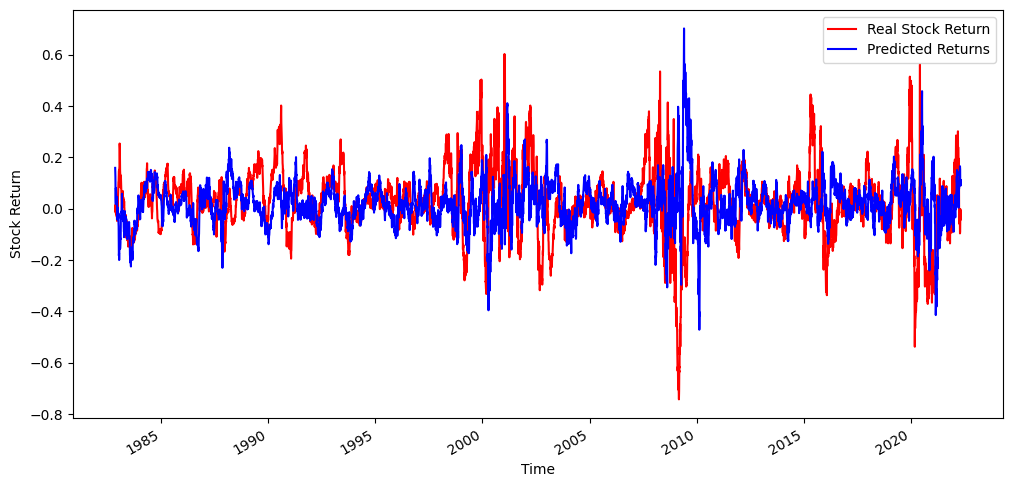

In [20]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df.plot(x="Date", y="Values", color="red", label="Real Stock Return", ax=ax)
df.plot(x="Date", y="Pred", color="blue", label="Predicted Returns", ax=ax)
plt.xlabel("Time")
plt.ylabel("Stock Return")
plt.legend()
plt.show()

From the previous graph we can observe that, at times, the predicted versus real Mom returns overlap, indicating that our model has some kind of prediction power. But of course, other times, the two go in completely opposite directions, which is not a very good sign. 

Next, we will perform **Backtesting** on a very simple strategy using the predicted returns:

- **Strategy**:

Our **strategy** will simply consist of going long on the Mom portfolio on a given day when the model predicts a positive return, and going short when the model predicts a negative one. Thus, if for a given day $d$ our model predicts a positive return, we would have gone long the previous day (at close prices) so that we will earn the Mom factor returns for that day $d$ (which we refer to as '*Ret*' in the DataFrame). Conversely, if the model predicts a negative return, we will go short the previous day so that we will earn minus day $d$ return ($-Ret_d$).

What we just described would be a classic long/short strategy. For comparison purposes, we also perform backtesting on a strategy that only goes long (omitting the short part in the previous strategy) and a Buy-and-hold strategy that simply invests in the Mom factor at the beginning of the test period and keeps the investment unaltered until the end of the period.

- **Backtesting**:

**Backtesting** is a very common way to evaluate a trading strategy. Intuitively, it consists of evaluating a trading strategy following the idea of '*how would I have done if I followed this strategy in a given period*'. For us, that period is the testing period. Following the strategy implies that at each point in time, we would be deciding with the information available just until that point in time. This is a very important condition we need to keep in mind because otherwise we would be contaminating our strategy and thus any inferences we draw on its validity.

\
Next, we calculate the positions that our strategy would keep each day in the backtest (that is 1 for long, -1 for short). By simply multiplying this *Positions* vector by the Mom factor daily returns (*Ret*), we can obtain the daily returns of our strategy. We can take a very similar approach to obtain daily returns of the long-only strategy. 

Then, we calculate the cumulative returns of the different strategies (long/short, long-only, and buy-and-hold) using the *lambda* feature in Python, as well as the final values obtained for our investment by the end of the testing period:

In [21]:
df["Positions"] = df["Pred"].apply(np.sign)
df["Strat_ret"] = df["Positions"].shift(1) * df["Ret"]
df["Positions_L"] = df["Positions"].shift(1)
df["Positions_L"][df["Positions_L"] == -1] = 0
df["Strat_ret_L"] = df["Positions_L"] * df["Ret"]
df["CumRet"] = df["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["CumRet_L"] = df["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["bhRet"] = df["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

Final_Return_L = np.prod(1 + df["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df["Ret"]) - 1

print("Strat Return Long Only =", Final_Return_L * 100, "%")
print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

/tmp/ipykernel_19/4012059038.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Positions_L"][df["Positions_L"] == -1] = 0
/tmp/ipykernel_19/4012059038.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

Strat Return Long Only = 1934.1467909416804 %
Strat Return = 491.6320380719581 %
Buy and Hold Return = 1909.8411102470113 %


Judging by the numbers, it is clear that we are not doing a very good job in timing the momentum factor. As before, let's see this graphically:

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df.plot(x="Date", y="bhRet", label="Buy&Hold", ax=ax)
df.plot(x="Date", y="CumRet_L", label="Strat Only Long", ax=ax)
df.plot(x="Date", y="CumRet", label="Strat Long/Short", ax=ax)
plt.xlabel("date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

df.describe()

So it would have clearly been better for us to simply have invested in the Mom factor portfolio and let our money stay there until the end of the period!

The previous table contains a bunch of different statistics for the different strategies that corroborate this idea. Notice that here we are simply looking at measures based on the distribution of returns according to each strategy followed. In practice, there are many more measures to assess the performance of a strategy in backtesting. 

You are probably familiar with most of these measures, like *Sharpe Ratio*, *Kurtosis*, etc. There are many more such as *Maximum DrawDown (MaxDD)*, *Calmar Ratio*, *Sortino Ratio*, etc. that we will use in future implementations of our neural network algorithms. 

\
If you want to learn more about these at this point, here, you have a number of (extra) resources (there are many more easily found online):

- **Backtesting basics**: https://medium.com/auquan/backtesting-basics-understanding-your-key-metrics-ed902c24c702

- **Some trading strategy performance metrics** (allegedly top metrics, but with a very narrow focus): https://improve-your.trade/blog/top-17-trading-metrics

- **Trading system and strategy performance metrics**: https://www.quantifiedstrategies.com/trading-strategy-and-system-performance-metrics/

- **12 ways to measure trading performance**: https://www.axi.com/int/blog/education/measure-your-trading-performance

- **5 key backtesting metrics and implementation**: https://blankly.finance/list-of-performance-metrics/

## **5. Conclusion**

In this lesson, we have used a very simple linear regression model to (i) introduce the framework of `Tensorflow` Keras, which will be where we develop all our future complex Neural Networks, and (ii) learn how to create a simple trading strategy and perform backtesting to evaluate its performance.

Sadly, our trading strategy based on linear regression delivered very poor results both in terms of performance and predictive power of the NN model. In the remaining lessons of the module, we will build a more complex NN and check how its predictive ability helps improve our trading strategy.
  
The first step for this is introducing multilayer perceptron (MLP) networks, which we will do in lesson 3. See you there!

**References**

- AQR. "Systematic Equities: A Closer Look." https://www.aqr.com/Learning-Center/Systematic-Equities/Systematic-Equities-A-Closer-Look.

- Asness, Clifford S., et al. "Value and Momentum Everywhere." *The Journal of Finance*, vol. 68, no. 3, 2013, pp. 929-985, https://onlinelibrary.wiley.com/doi/abs/10.1111/jofi.12021?casa_token=vxQDrj_UikoAAAAA:hXo8tu-G8xQb6CxRiS1C2hk8zLyYM6rlYrl3E8DqUnTY2TG1m_F2me8XUChr9S88W-csmUczqZQ44E8. 

- Auquan. "Backtesting Basics: Understanding Your Key Metrics." *Medium*, 21 July 2020, https://medium.com/auquan/backtesting-basics-understanding-your-key-metrics-ed902c24c702.

- BlackRock. "Factor-Based Investing." BlackRock, Inc. https://www.blackrock.com/uk/professionals/solutions/factor-based-investing.

- Campbell, John Y., and Samuel B. Thompson. "Predicting Excess Stock Returns out of Sample: Can Anything Beat the Historical Average?" *The Review of Financial Studies*, vol. 21, no. 4, 2008, pp. 1509-1531.

- Cutkovic, Milan. "12 Ways to Measure Your Trading Performance." Axi, 28 September 2021, https://www.axi.com/int/blog/education/measure-your-trading-performance. 

- Daniel, Kent, and Tobias J. Moskowitz. "Momentum Crashes." *Journal of Financial Economics*, vol. 122, no. 2, 2016, pp. 221-247, https://www.sciencedirect.com/science/article/pii/S0304405X16301490.

- Ehsani, Sina, and Juhani T. Linnainmaa. "Factor Momentum and the Momentum Factor." *The Journal of Finance*, vol. 77, no. 3, 2022, pp. 1877-1919, https://onlinelibrary.wiley.com/doi/full/10.1111/jofi.13131?casa_token=oWY7-8sCYqkAAAAA%3A-HrzsyemLuXf0lQyYMT9vxFNyNQugJsMfaY39EAeTCjClDlAPHdU_fqS4z2-LpVrUO7li2wQmIphYXA.

- Erwin. "The Top 17 Trading Metrics (and Why You Should Care)." *EB Worx*, https://improve-your.trade/blog/top-17-trading-metrics. 

- Fan, Brandon. "Trading Algos - 5 Key Backtesting Metrics and How to Implement Them." Blankly, 7 Jan. 2022, https://blankly.finance/list-of-performance-metrics/. 

- Fama, Eugene F., and Kenneth R. French. "Common Risk Factors in the Returns on Stocks and Bonds." *Journal of Financial Economics*, vol. 33, no. 1, 1993, pp. 3-56, (https://doi.org/10.1016/0304-405X(93)90023-5).

- Fama, Eugene F., and Kenneth R. French. "The Cross-Section of Expected Stock Returns." *The Journal of Finance*, vol. 47, no. 2, 1992, pp. 427-465, https://www.jstor.org/stable/2329112.

- French, Kenneth R. "Current Research Returns." https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html. 

- French, Kenneth R. "Detail for 10 Returns Formed Daily on Momentum." https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_10_port_form_pr_12_2_daily.html. 

- Harvey, Campbell R., et al. "... and the Cross-Section of Expected Returns." *The Review of Financial Studies*, vol. 29, no. 1, 2016, pp. 5-68.

- Huang, Dashan, et al. "Time Series Momentum: Is It There?" *Journal of Financial Economics*, vol. 135, no. 3, 2020, pp. 774-794, https://core.ac.uk/download/pdf/287750773.pdf.

- Jegadeesh, Narasimhan, and Sheridan Titman. "Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency." *The Journal of Finance*, vol. 48, no. 1, 1993, pp. 65-91.

- Moskowitz, Tobias J., et al. "Time Series Momentum." *Journal of Financial Economics*, vol. 104, no. 2, 2012, pp. 228-250, https://www.sciencedirect.com/science/article/pii/S0304405X11002613.

- Mullins, Jr., David W. "Does the Capital Asset Pricing Model Work?" *Harvard Business Review*, 1982, https://hbr.org/1982/01/does-the-capital-asset-pricing-model-work.

- Nielson, Darby, et al. *An Overview of Factor Investing: The Merits of Factors as Potential Building Blocks for Portfolio Construction.* Fidelity Investments, 2016.

- Quantified Strategies for Traders. "Trading System and Strategy Performance Metrics (What Is It and How to Use It)." 12 October 2022, https://www.quantifiedstrategies.com/trading-strategy-and-system-performance-metrics/. 

- Vanguard. "Factor-Based Strategies." The Vanguard Group, Inc. https://advisors.vanguard.com/investments/approach/factor-based-strategies.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
